# 06b - Improved Baseline Models

**Improvements over 06_baseline_model**:
1. Reduce to 6 classes (merge DTE90 into DTE60)
2. Drop price-level and redundant correlated features
3. Hyperparameter tuning with Optuna
4. Two-stage model (moneyness + maturity separately)
5. SMOTE oversampling for minority classes
6. LightGBM as additional model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib
import warnings
warnings.filterwarnings('ignore')
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)


## 1. Load and Prepare Data

In [2]:
# Load modeling data
data = pd.read_parquet(PROCESSED / 'modeling_data.parquet')
print(f"Original data: {data.shape}")
print(f"Original classes: 9")
print(f"Original label distribution:")
print(data['label'].value_counts().sort_index())

Original data: (671, 37)
Original classes: 9
Original label distribution:
label
0    137
1    148
2     25
3     40
4     91
5     26
6     63
7    112
8     29
Name: count, dtype: int64


## 2. Improvement 1: Reduce to 6 Classes

Merge DTE90 into DTE60; the 3 DTE90 buckets have only 25-29 samples each and are rarely optimal.

In [4]:
# Remap: merge DTE90 into DTE60
# Original: ATM_DTE30=0, ATM_DTE60=1, ATM_DTE90=2, OTM5_DTE30=3, OTM5_DTE60=4, OTM5_DTE90=5, OTM10_DTE30=6, OTM10_DTE60=7, OTM10_DTE90=8
# New 6-class: ATM_SHORT=0, ATM_LONG=1, OTM5_SHORT=2, OTM5_LONG=3, OTM10_SHORT=4, OTM10_LONG=5

bucket_remap = {
    'ATM_DTE30': 'ATM_SHORT',
    'ATM_DTE60': 'ATM_LONG',
    'ATM_DTE90': 'ATM_LONG',       # merged
    'OTM5_DTE30': 'OTM5_SHORT',
    'OTM5_DTE60': 'OTM5_LONG',
    'OTM5_DTE90': 'OTM5_LONG',     # merged
    'OTM10_DTE30': 'OTM10_SHORT',
    'OTM10_DTE60': 'OTM10_LONG',
    'OTM10_DTE90': 'OTM10_LONG',   # merged
}

label_map_6 = {
    'ATM_SHORT': 0, 'ATM_LONG': 1,
    'OTM5_SHORT': 2, 'OTM5_LONG': 3,
    'OTM10_SHORT': 4, 'OTM10_LONG': 5
}
label_to_bucket_6 = {v: k for k, v in label_map_6.items()}

data['bucket_6'] = data['best_bucket'].map(bucket_remap)
data['label_6'] = data['bucket_6'].map(label_map_6)

print("6-Class distribution:")
for label in range(6):
    count = (data['label_6'] == label).sum()
    pct = count / len(data) * 100
    print(f"  {label} ({label_to_bucket_6[label]}): {count} ({pct:.1f}%)")

imbalance = data['label_6'].value_counts()
print(f"\nImbalance ratio: {imbalance.max()/imbalance.min():.1f}x (was 5.9x with 9 classes)")

6-Class distribution:
  0 (ATM_SHORT): 137 (20.4%)
  1 (ATM_LONG): 173 (25.8%)
  2 (OTM5_SHORT): 40 (6.0%)
  3 (OTM5_LONG): 117 (17.4%)
  4 (OTM10_SHORT): 63 (9.4%)
  5 (OTM10_LONG): 141 (21.0%)

Imbalance ratio: 4.3x (was 5.9x with 9 classes)


## 3. Improvement 2: Feature Pruning

Drop price-level features and one from each highly correlated pair.

In [5]:
# Features to drop:
# - adjusted_close: price level leaks ticker identity, not generalizable
# - volume: absolute volume also ticker-specific
# - operating_margin: r=0.94 with net_margin (keep net_margin)
# - price_to_sma50: r=0.89 with mom_21d (keep mom_21d)
# - vol_10d: r~0.85 with vol_21d (keep vol_21d)

drop_features = ['adjusted_close', 'volume', 'operating_margin', 'price_to_sma50', 'vol_10d']

exclude_cols = ['symbol', 'decision_date', 'year_month', 'label', 'best_bucket',
                'best_return', 'fiscalDateEnding', 'year', 'bucket_6', 'label_6']

feature_cols = [c for c in data.columns if c not in exclude_cols and c not in drop_features]

print(f"Features: {len(feature_cols)} (dropped {len(drop_features)})")
print(f"Dropped: {drop_features}")
print(f"Kept: {feature_cols}")

Features: 25 (dropped 5)
Dropped: ['adjusted_close', 'volume', 'operating_margin', 'price_to_sma50', 'vol_10d']
Kept: ['vol_21d', 'vol_63d', 'mom_5d', 'mom_21d', 'mom_63d', 'price_to_sma21', 'price_to_sma200', 'sma21_above_sma50', 'sma50_above_sma200', 'drawdown_63d', 'drawdown_252d', 'volume_ratio', 'high_vol_regime', 'gross_margin', 'net_margin', 'revenue_growth_yoy', 'earnings_growth_yoy', 'debt_to_equity', 'cash_ratio', 'roe', 'roa', 'pe_ratio', 'ps_ratio', 'ev_ebitda', 'fcf_yield']


In [6]:
# Prepare X and y (6-class)
X = data[feature_cols].copy()
y = data['label_6'].copy()

# Fill missing with median
X = X.fillna(X.median())
assert X.isnull().sum().sum() == 0

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"\nTrain distribution:")
print(y_train.value_counts().sort_index())

Train: 536, Test: 135
Features: 25

Train distribution:
label_6
0    109
1    138
2     32
3     94
4     50
5    113
Name: count, dtype: int64


## 4. Improvement 3: SMOTE Oversampling

In [7]:
# Apply SMOTE to balance training set
smote = SMOTE(random_state=SEED, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {len(X_train)} samples")
print(f"After SMOTE:  {len(X_train_sm)} samples")
print(f"\nBalanced distribution:")
print(y_train_sm.value_counts().sort_index())

Before SMOTE: 536 samples
After SMOTE:  828 samples

Balanced distribution:
label_6
0    138
1    138
2    138
3    138
4    138
5    138
Name: count, dtype: int64


## 5. Baseline model check on new features
- 6 Classes with Clean Features

In [8]:
# Quick baseline to see improvement from class reduction + feature pruning alone
rf_base = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1)
rf_base.fit(X_train_sm, y_train_sm)
y_pred_base = rf_base.predict(X_test)

base_acc = accuracy_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base, average='macro')

print(f"6-Class RF Baseline (SMOTE):")
print(f"  Accuracy:  {base_acc:.4f}")
print(f"  Macro F1:  {base_f1:.4f}")
print(f"\nCompare to 9-class RF: Accuracy=0.3333, Macro F1=0.3103")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_base, target_names=[label_to_bucket_6[i] for i in range(6)]))

6-Class RF Baseline (SMOTE):
  Accuracy:  0.4889
  Macro F1:  0.4488

Compare to 9-class RF: Accuracy=0.3333, Macro F1=0.3103

Classification Report:
              precision    recall  f1-score   support

   ATM_SHORT       0.52      0.46      0.49        28
    ATM_LONG       0.61      0.63      0.62        35
  OTM5_SHORT       0.05      0.12      0.07         8
   OTM5_LONG       0.56      0.39      0.46        23
 OTM10_SHORT       0.50      0.54      0.52        13
  OTM10_LONG       0.56      0.50      0.53        28

    accuracy                           0.49       135
   macro avg       0.47      0.44      0.45       135
weighted avg       0.53      0.49      0.50       135



## 6. Improvement 3: Hyperparameter Tuning with Optuna

Tune Random Forest, XGBoost, and LightGBM.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 4, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': SEED, 'n_jobs': -1
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': SEED, 'use_label_encoder': False,
        'eval_metric': 'mlogloss', 'n_jobs': -1
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': SEED, 'verbose': -1, 'n_jobs': -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_sm, y_train_sm, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

print("Objective functions defined. Starting tuning...")

Objective functions defined. Starting tuning...


In [10]:
# Tune Random Forest with 20 trials
study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)
print(f"RF best CV Macro F1: {study_rf.best_value:.4f}")
print(f"RF best params: {study_rf.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 17. Best value: 0.59906: 100%|██████████| 20/20 [00:14<00:00,  1.43it/s] 

RF best CV Macro F1: 0.5991
RF best params: {'n_estimators': 303, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'sqrt'}


In [11]:
# Tune XGBoost with 20 trials
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)
print(f"XGB best CV Macro F1: {study_xgb.best_value:.4f}")
print(f"XGB best params: {study_xgb.best_params}")

Best trial: 14. Best value: 0.587029: 100%|██████████| 20/20 [00:09<00:00,  2.04it/s]

XGB best CV Macro F1: 0.5870
XGB best params: {'n_estimators': 417, 'max_depth': 9, 'learning_rate': 0.15754911501411575, 'subsample': 0.7664125867669591, 'colsample_bytree': 0.9969831480026861, 'min_child_weight': 3, 'gamma': 0.49302866058105177, 'reg_alpha': 4.6335021995037196e-05, 'reg_lambda': 0.022097530571713292}


In [12]:
# Tune LightGBM with 20 trials
study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(objective_lgbm, n_trials=20, show_progress_bar=True)
print(f"LGBM best CV Macro F1: {study_lgbm.best_value:.4f}")
print(f"LGBM best params: {study_lgbm.best_params}")

Best trial: 11. Best value: 0.636311: 100%|██████████| 20/20 [03:07<00:00,  9.39s/it]

LGBM best CV Macro F1: 0.6363
LGBM best params: {'n_estimators': 487, 'max_depth': 12, 'learning_rate': 0.19265640527744946, 'num_leaves': 75, 'subsample': 0.8278877235479689, 'colsample_bytree': 0.6181320282499216, 'min_child_samples': 6, 'reg_alpha': 0.0014441715954420077, 'reg_lambda': 0.0021142323970375567}


## 7. Evaluate Tuned Models on Test Set

In [13]:
# Train with best params on SMOTE data, evaluate on original test
rf_tuned = RandomForestClassifier(**study_rf.best_params, random_state=SEED, n_jobs=-1)
rf_tuned.fit(X_train_sm, y_train_sm)
y_pred_rf = rf_tuned.predict(X_test)

xgb_tuned = XGBClassifier(**study_xgb.best_params, random_state=SEED, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1)
xgb_tuned.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb_tuned.predict(X_test)

lgbm_tuned = LGBMClassifier(**study_lgbm.best_params, random_state=SEED, verbose=-1, n_jobs=-1)
lgbm_tuned.fit(X_train_sm, y_train_sm)
y_pred_lgbm = lgbm_tuned.predict(X_test)

# Metrics
results = {}
for name, y_pred in [('RF_tuned', y_pred_rf), ('XGB_tuned', y_pred_xgb), ('LGBM_tuned', y_pred_lgbm)]:
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Macro F1': f1_score(y_test, y_pred, average='macro'),
        'Weighted F1': f1_score(y_test, y_pred, average='weighted'),
    }

results_df = pd.DataFrame(results).T
print("Tuned Model Results (6-class, SMOTE, pruned features):")
print(results_df.round(4))

print(f"\n--- Improvement over 9-class baseline ---")
print(f"9-class RF baseline:  Accuracy=0.3333, Macro F1=0.3103")
best_model_name = results_df['Macro F1'].idxmax()
best_f1 = results_df.loc[best_model_name, 'Macro F1']
print(f"Best 6-class tuned:   Accuracy={results_df.loc[best_model_name, 'Accuracy']:.4f}, Macro F1={best_f1:.4f}")
print(f"Macro F1 improvement: {(best_f1 - 0.3103) / 0.3103 * 100:+.1f}%")

Tuned Model Results (6-class, SMOTE, pruned features):
            Accuracy  Macro F1  Weighted F1
RF_tuned      0.4667    0.4176       0.4892
XGB_tuned     0.4741    0.4192       0.4750
LGBM_tuned    0.4074    0.3425       0.4064

--- Improvement over 9-class baseline ---
9-class RF baseline:  Accuracy=0.3333, Macro F1=0.3103
Best 6-class tuned:   Accuracy=0.4741, Macro F1=0.4192
Macro F1 improvement: +35.1%


In [14]:
# Classification reports for all models
for name, y_pred in [('RF Tuned', y_pred_rf), ('XGB Tuned', y_pred_xgb), ('LGBM Tuned', y_pred_lgbm)]:
    print(f"{name}:")
    print(classification_report(y_test, y_pred, target_names=[label_to_bucket_6[i] for i in range(6)]))

RF Tuned:
              precision    recall  f1-score   support

   ATM_SHORT       0.48      0.43      0.45        28
    ATM_LONG       0.63      0.63      0.63        35
  OTM5_SHORT       0.00      0.00      0.00         8
   OTM5_LONG       0.56      0.39      0.46        23
 OTM10_SHORT       0.38      0.46      0.41        13
  OTM10_LONG       0.61      0.50      0.55        28

    accuracy                           0.47       135
   macro avg       0.44      0.40      0.42       135
weighted avg       0.52      0.47      0.49       135

XGB Tuned:
              precision    recall  f1-score   support

   ATM_SHORT       0.60      0.32      0.42        28
    ATM_LONG       0.59      0.69      0.63        35
  OTM5_SHORT       0.07      0.12      0.09         8
   OTM5_LONG       0.42      0.35      0.38        23
 OTM10_SHORT       0.41      0.54      0.47        13
  OTM10_LONG       0.52      0.54      0.53        28

    accuracy                           0.47       135
  

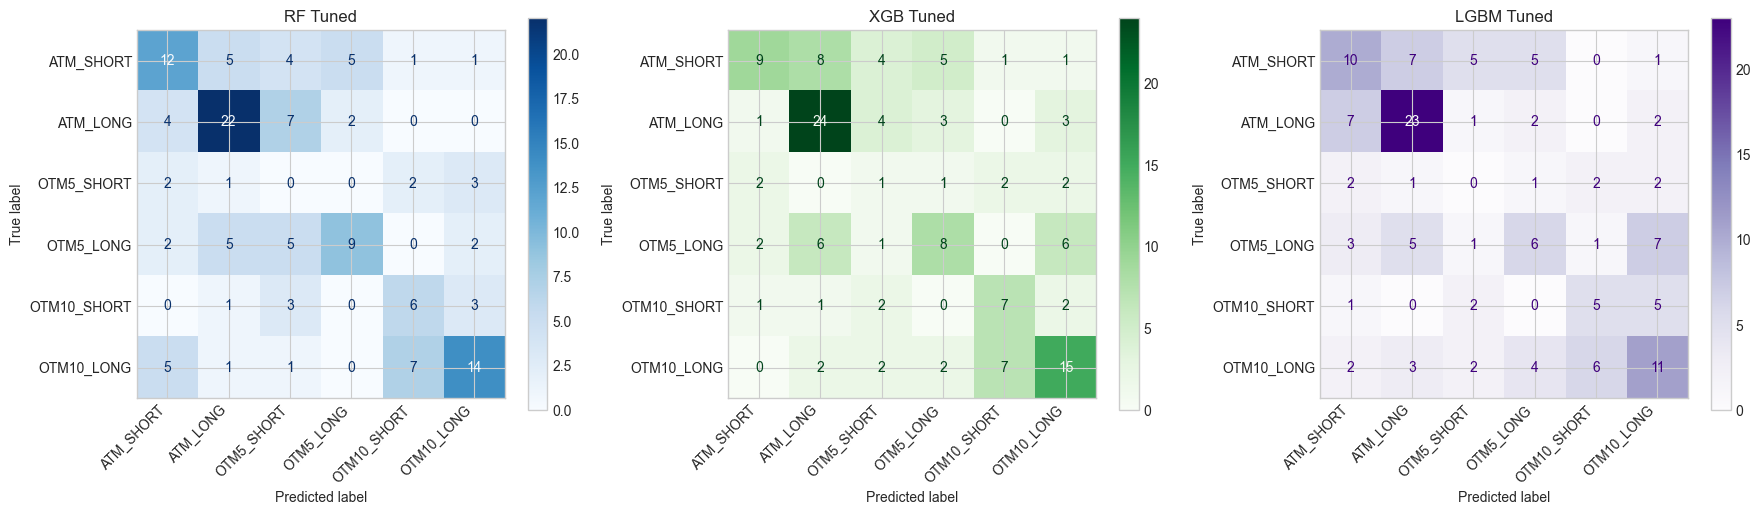

In [15]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred, cmap) in zip(axes, [
    ('RF Tuned', y_pred_rf, 'Blues'),
    ('XGB Tuned', y_pred_xgb, 'Greens'),
    ('LGBM Tuned', y_pred_lgbm, 'Purples')
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[label_to_bucket_6[i] for i in range(6)])
    disp.plot(ax=ax, cmap=cmap, values_format='d')
    ax.set_title(name)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('../reports/figures/improved_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Improvement 4: Two-Stage Model

Predict moneyness (3 classes) and maturity (2 classes) separately.

In [16]:
# Create separate targets
data['moneyness'] = data['best_bucket'].str.split('_').str[0]  # ATM, OTM5, OTM10
data['maturity'] = data['bucket_6'].str.split('_').str[1]      # SHORT, LONG

moneyness_map = {'ATM': 0, 'OTM5': 1, 'OTM10': 2}
maturity_map = {'SHORT': 0, 'LONG': 1}

data['y_moneyness'] = data['moneyness'].map(moneyness_map)
data['y_maturity'] = data['maturity'].map(maturity_map)

print("Moneyness distribution:")
print(data['moneyness'].value_counts())
print(f"\nMaturity distribution:")
print(data['maturity'].value_counts())

Moneyness distribution:
moneyness
ATM      310
OTM10    204
OTM5     157
Name: count, dtype: int64

Maturity distribution:
maturity
LONG     431
SHORT    240
Name: count, dtype: int64


### Moneyness

In [17]:
#  Moneyness (3-class)
y_money = data['y_moneyness']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_money, test_size=0.2, random_state=SEED, stratify=y_money
)

# SMOTE
sm_m = SMOTE(random_state=SEED, k_neighbors=3)
X_tr_m_sm, y_tr_m_sm = sm_m.fit_resample(X_train_m, y_train_m)

# Tune with Optuna
def objective_money(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'random_state': SEED, 'verbose': -1, 'n_jobs': -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_tr_m_sm, y_tr_m_sm, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study_money = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_money.optimize(objective_money, n_trials=20, show_progress_bar=True)

money_model = LGBMClassifier(**study_money.best_params, random_state=SEED, verbose=-1, n_jobs=-1)
money_model.fit(X_tr_m_sm, y_tr_m_sm)
y_pred_money = money_model.predict(X_test_m)

money_acc = accuracy_score(y_test_m, y_pred_money)
money_f1 = f1_score(y_test_m, y_pred_money, average='macro')
print(f"Stage 1 — Moneyness (3-class):")
print(f"  Accuracy: {money_acc:.4f}")
print(f"  Macro F1: {money_f1:.4f}")
print(classification_report(y_test_m, y_pred_money, target_names=['ATM', 'OTM5', 'OTM10']))

  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 15. Best value: 0.758065: 100%|██████████| 20/20 [01:49<00:00,  5.45s/it]


Stage 1 — Moneyness (3-class):
  Accuracy: 0.5852
  Macro F1: 0.5472
              precision    recall  f1-score   support

         ATM       0.65      0.73      0.69        62
        OTM5       0.35      0.34      0.35        32
       OTM10       0.66      0.56      0.61        41

    accuracy                           0.59       135
   macro avg       0.55      0.54      0.55       135
weighted avg       0.58      0.59      0.58       135



### Maturity

In [18]:
#  Maturity (2-class)
y_mat = data['y_maturity']
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y_mat, test_size=0.2, random_state=SEED, stratify=y_mat
)

sm_t = SMOTE(random_state=SEED, k_neighbors=3)
X_tr_t_sm, y_tr_t_sm = sm_t.fit_resample(X_train_t, y_train_t)

def objective_mat(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'random_state': SEED, 'verbose': -1, 'n_jobs': -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_tr_t_sm, y_tr_t_sm, cv=cv, scoring='f1_macro', n_jobs=-1)
    return scores.mean()

study_mat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_mat.optimize(objective_mat, n_trials=20, show_progress_bar=True)

mat_model = LGBMClassifier(**study_mat.best_params, random_state=SEED, verbose=-1, n_jobs=-1)
mat_model.fit(X_tr_t_sm, y_tr_t_sm)
y_pred_mat = mat_model.predict(X_test_t)

mat_acc = accuracy_score(y_test_t, y_pred_mat)
mat_f1 = f1_score(y_test_t, y_pred_mat, average='macro')
print(f"Stage 2 — Maturity (2-class):")
print(f"  Accuracy: {mat_acc:.4f}")
print(f"  Macro F1: {mat_f1:.4f}")
print(classification_report(y_test_t, y_pred_mat, target_names=['SHORT', 'LONG']))

Best trial: 11. Best value: 0.715697: 100%|██████████| 20/20 [00:43<00:00,  2.17s/it]


Stage 2 — Maturity (2-class):
  Accuracy: 0.5704
  Macro F1: 0.5355
              precision    recall  f1-score   support

       SHORT       0.40      0.42      0.41        48
        LONG       0.67      0.66      0.66        87

    accuracy                           0.57       135
   macro avg       0.54      0.54      0.54       135
weighted avg       0.57      0.57      0.57       135



In [19]:
# Combine two-stage predictions into 6-class
# Use same test indices for fair comparison
X_test_2s = X.loc[X_test.index]
pred_money_2s = money_model.predict(X_test_2s)
pred_mat_2s = mat_model.predict(X_test_2s)

# Combine: moneyness * 2 + maturity = 6-class label
y_pred_2stage = pred_money_2s * 2 + pred_mat_2s

twostage_acc = accuracy_score(y_test, y_pred_2stage)
twostage_f1 = f1_score(y_test, y_pred_2stage, average='macro')

print(f"Two-Stage Combined (6-class):")
print(f"  Accuracy:  {twostage_acc:.4f}")
print(f"  Macro F1:  {twostage_f1:.4f}")
print(classification_report(y_test, y_pred_2stage, target_names=[label_to_bucket_6[i] for i in range(6)]))

Two-Stage Combined (6-class):
  Accuracy:  0.8148
  Macro F1:  0.7864
              precision    recall  f1-score   support

   ATM_SHORT       0.95      0.68      0.79        28
    ATM_LONG       0.82      0.91      0.86        35
  OTM5_SHORT       0.62      0.62      0.62         8
   OTM5_LONG       0.77      0.87      0.82        23
 OTM10_SHORT       0.67      0.92      0.77        13
  OTM10_LONG       0.92      0.79      0.85        28

    accuracy                           0.81       135
   macro avg       0.79      0.80      0.79       135
weighted avg       0.83      0.81      0.81       135



## 9. Feature Importance (Best Model)

Best model: Two-Stage
            Accuracy  Macro F1  Weighted F1
RF_tuned      0.4667    0.4176       0.4892
XGB_tuned     0.4741    0.4192       0.4750
LGBM_tuned    0.4074    0.3425       0.4064
Two-Stage     0.8148    0.7864       0.8146


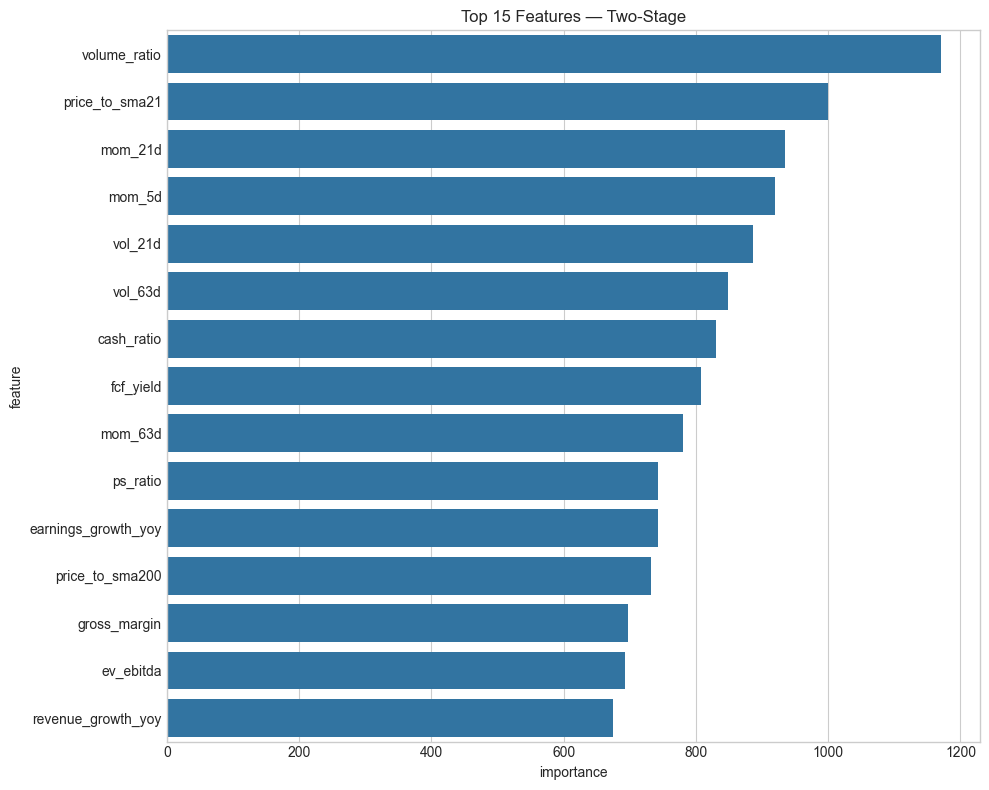

In [20]:
# Get best single model
all_results = results.copy()
all_results['Two-Stage'] = {
    'Accuracy': twostage_acc,
    'Macro F1': twostage_f1,
    'Weighted F1': f1_score(y_test, y_pred_2stage, average='weighted'),
}
all_results_df = pd.DataFrame(all_results).T.round(4)

best_name = all_results_df['Macro F1'].idxmax()
print(f"Best model: {best_name}")
print(all_results_df)

# Feature importance from best single model
if best_name == 'RF_tuned':
    best_model = rf_tuned
elif best_name == 'XGB_tuned':
    best_model = xgb_tuned
else:
    best_model = lgbm_tuned

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=importance.head(15), x='importance', y='feature', ax=ax)
ax.set_title(f'Top 15 Features — {best_name}')
plt.tight_layout()
plt.savefig('../reports/figures/improved_feature_importance.png', dpi=150)
plt.show()

## 10. Final Comparison: Old vs New

Full Model Comparison:
                     Model  Accuracy  Macro F1
     9-class RF (baseline)    0.3333    0.3103
    9-class XGB (baseline)    0.2741    0.2490
  6-class RF (tuned+SMOTE)    0.4667    0.4176
 6-class XGB (tuned+SMOTE)    0.4741    0.4192
6-class LGBM (tuned+SMOTE)    0.4074    0.3425
         6-class Two-Stage    0.8148    0.7864


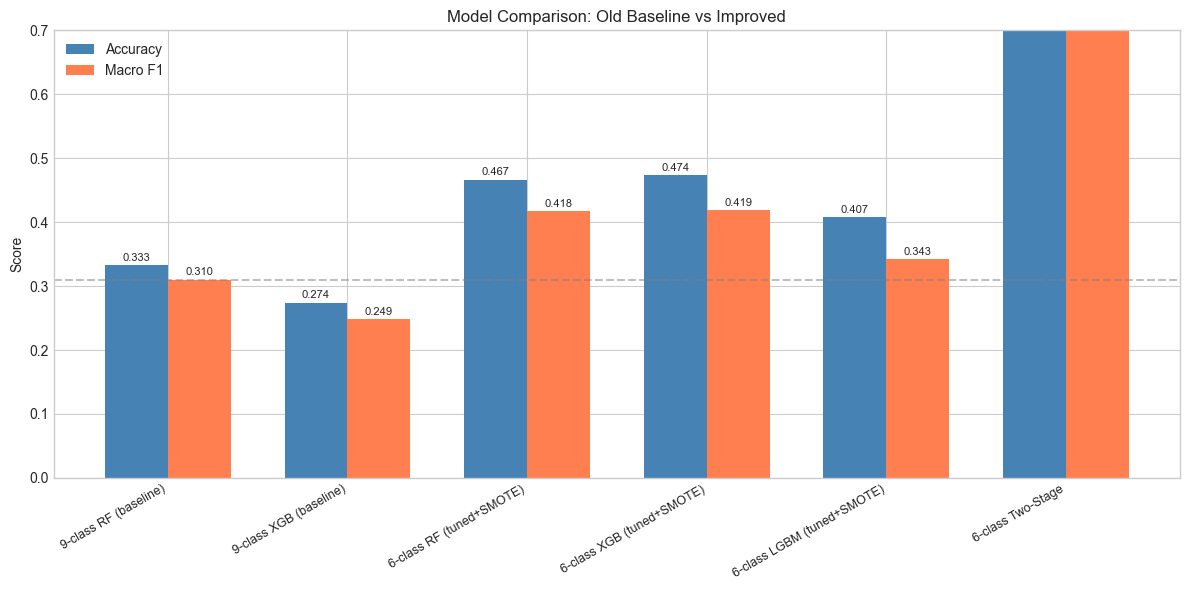

In [21]:
# Summary table
comparison = pd.DataFrame({
    'Model': [
        '9-class RF (baseline)',
        '9-class XGB (baseline)',
        '6-class RF (tuned+SMOTE)',
        '6-class XGB (tuned+SMOTE)',
        '6-class LGBM (tuned+SMOTE)',
        '6-class Two-Stage',
    ],
    'Accuracy': [
        0.3333, 0.2741,
        results['RF_tuned']['Accuracy'],
        results['XGB_tuned']['Accuracy'],
        results['LGBM_tuned']['Accuracy'],
        twostage_acc,
    ],
    'Macro F1': [
        0.3103, 0.2490,
        results['RF_tuned']['Macro F1'],
        results['XGB_tuned']['Macro F1'],
        results['LGBM_tuned']['Macro F1'],
        twostage_f1,
    ]
}).round(4)

print("Full Model Comparison:")
print(comparison.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison))
width = 0.35
bars1 = ax.bar(x - width/2, comparison['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, comparison['Macro F1'], width, label='Macro F1', color='coral')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Old Baseline vs Improved')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=30, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0, 0.7)
ax.axhline(y=0.3103, color='gray', linestyle='--', alpha=0.5, label='9-class baseline F1')

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/old_vs_new_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Best Models

In [22]:
# Save all tuned models
joblib.dump(rf_tuned, MODELS / 'rf_tuned_6class.joblib')
joblib.dump(xgb_tuned, MODELS / 'xgb_tuned_6class.joblib')
joblib.dump(lgbm_tuned, MODELS / 'lgbm_tuned_6class.joblib')
joblib.dump(money_model, MODELS / 'twostage_moneyness.joblib')
joblib.dump(mat_model, MODELS / 'twostage_maturity.joblib')

# Save metadata
metadata = {
    'feature_cols': feature_cols,
    'label_map_6': label_map_6,
    'moneyness_map': moneyness_map,
    'maturity_map': maturity_map,
    'best_model': best_name,
    'best_rf_params': study_rf.best_params,
    'best_xgb_params': study_xgb.best_params,
    'best_lgbm_params': study_lgbm.best_params,
}
with open(MODELS / 'improved_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Save comparison results
comparison.to_csv(PROCESSED / 'improved_results.csv', index=False)

print("All models and results saved.")
print(f"\nBest model: {best_name} (Macro F1: {all_results_df.loc[best_name, 'Macro F1']:.4f})")

All models and results saved.

Best model: Two-Stage (Macro F1: 0.7864)
